# IT00CJ11 Computer Vision (5 cr. ECTS), spring 2025

***Direct computational methods and deep learning for vision***

***Camera models***

Here, we will look at modeling cameras and how to effectively use such models. Previously, we covered image to image mappings and transforms. To handle mappings between 3D and images, the projection properties of the camera generating the image needs to be part of the mapping. Here we show how to determine camera properties and in Solem you can read about how to use image projections for applications like augmented reality.

***The pin-hole camera model***

The pin-hole camera model (or sometimes projective camera model) is a widely used camera model in computer vision. It is simple and accurate enough for most applications. The name comes from the type of camera, like a camera obscura, that collects light through a small hole to the inside of a dark box or room. In the pin-hole camera model, light passes through a single point, the camera center,$C$ , before it is projected onto an image plane. 
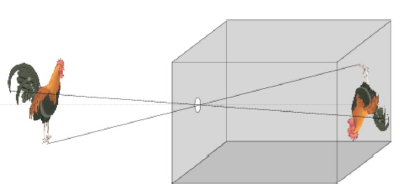

The figure on the left below shows the principle behond the illustration above and the one on the right an analogue where the image plane is drawn in front of the camera center. The image plane in an actual camera would be upside down behind the camera center, but the model is the same.
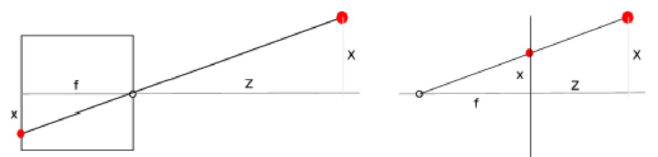

The projection properties of a pin-hole camera can be derived from this illustration and the assumption that the image axis is aligned with the $x$ and $y$ axis of a 3D coordinate system. The optical axis of the camera then coincides with the $z$ axis and the projection follows from similar triangles. By adding rotation and translation to put a 3D point in this coordinate system before projecting, the complete projection transform follows.

With a pin-hole camera, a 3D point $\mathbf{X}$ is projected to an image point $\mathbf{x} = \left[ x, y, \frac{Z}{\lambda} \right]^{\mathrm{T}}$ (both expressed in homogeneous coordinates) as

$$\lambda \ \mathbf{x} = P \ \mathbf{X} \ .$$

Here, the $3 \times 4$ matrix $P$ is called the camera matrix (or projection matrix). Note that
the 3D point $\mathbf{X}$ has four elements in homogeneous coordinates, $\mathbf{X} = \left[ X, Y, Z, W \right]^{\mathrm{T}}$. The scalar $\lambda$ is the inverse depth of the 3D point and is needed if we want all coordinates to
be homogeneous with the last value normalized to one.

***The camera matrix***

This matrix can be decomposed into the form

$$P = K \ \left[ R \ | \ \mathbf{t} \right]$$

where $R$, ($3 \times 3$) is a rotation matrix describing the orientation of the camera, $\mathbf{t}$ ($3 \times 1$) a 3D translation vector describing the position of the camera center, and the intrinsic calibration matrix $K$ ($3 \times 3$) describing the projection properties of the camera.

This calibration matrix depends only on the camera properties and is in a general form written as

$$K = \left( \begin{array}{ccc} \alpha f & s & d_x \\ 0 & f & d_y \\ 0 & 0 & 1 \end{array} \right)$$

The focal length, $f$, is the distance between the image plane and the camera center. The skew, $s$, is only used if the pixel array in the sensor is skewed and can in most cases safely be set to zero. This gives

$$K = \left( \begin{array}{ccc} f_x & 0 & d_x \\ 0 & f_y & d_y \\ 0 & 0 & 1 \end{array} \right)$$

where we used the alternative notation $f_x$ and $f_y$, with $f_x = \alpha \ f_y$.

The aspect ratio, $\alpha$ is used for non-square pixel elements. It is often safe to assume $\alpha = 1$. With this assumption, the matrix becomes

$$K = \left( \begin{array}{ccc} f & 0 & d_x \\ 0 & f & d_y \\ 0 & 0 & 1 \end{array} \right)$$

Besides the focal length, the only remaining parameters are the coordinates of the optical center (sometimes called the principal point), the image point $d = \left[ d_x , d_y \right]$ where the optical axis intersects the image plane. Since this is usually in the center of the image and image coordinates are measured from the top-left corner, these values are often well approximated with half the width and height of the image. It is worth noting that in this last case the only unknown variable is the focal length $f$.


***Projecting 3D points***

Let’s create a camera class to handle all the operations we need for modeling cameras and projections:

In [1]:
from numpy import *
from scipy import linalg

def rq(A):
    from scipy.linalg import qr
    
    Q,R = qr(flipud(A).T)
    R = flipud(R.T)
    Q = Q.T
    
    return R[:,::-1],Q[::-1,:]

class Camera(object):
    """ Class for representing pin-hole cameras. """
    
    def __init__(self,P):
        """ Initialize P = K[R|t] camera model. """
        self.P = P
        self.K = None # calibration matrix
        self.R = None # rotation
        self.t = None # translation
        self.c = None # camera center
        
    
    def project(self,X):
        """    Project points in X (4*n array) and normalize coordinates. """
        
        x = dot(self.P,X)
        for i in range(3):
            x[i] /= x[2]    
        return x
        
        
    def factor(self):
        """    Factorize the camera matrix into K,R,t as P = K[R|t]. """
        
        # factor first 3*3 part
        K,R = rq(self.P[:,:3])
        
        # make diagonal of K positive
        T = diag(sign(diag(K)))
        if linalg.det(T) < 0:
            T[1,1] *= -1
        
        self.K = dot(K,T)
        self.R = dot(T,R) # T is its own inverse
        self.t = dot(linalg.inv(self.K),self.P[:,3])
        
        return self.K, self.R, self.t
        
    
    def center(self):
        """    Compute and return the camera center. """
    
        if self.c is not None:
            return self.c
        else:
            # compute c by factoring
            self.factor()
            self.c = -dot(self.R.T,self.t)
            return self.c            

The example below shows how to project 3D points into an image view. In this example, we will use one of the Oxfordmulti-view datasets, the “ModelHouse” data set. We use the file house.p3d file for this:

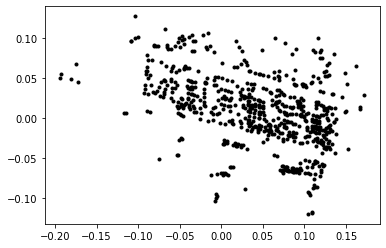

In [2]:
from PIL import Image
from numpy import *
from pylab import *
# load points
points = loadtxt('house.p3d').T
points = vstack((points,np.ones(points.shape[1])))
# setup camera
P = hstack((eye(3),array([[0],[0],[-10]])))
cam = Camera(P)
x = cam.project(points)
# plot projection
figure()
plot(x[0],x[1],'k.')
show()

First, we make the points into homogeneous coordinates and create a Camera object with a projection matrix before projection the 3D points and plotting them. The result looks like the above plot. 

To see how moving the camera changes the projection, try the following piece of code that incrementally rotates the camera around a random 3D axis:

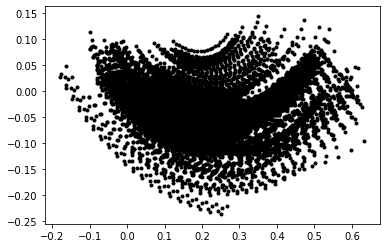

In [3]:
from PIL import Image
from numpy import *
import numpy.random as rnd
import scipy.linalg as la
from pylab import *

def rotation_matrix(a):
  """ Creates a 3D rotation matrix for rotation
  around the axis of the vector a. """
  R = eye(4)
  R[:3,:3] = la.expm([[0,-a[2],a[1]],[a[2],0,-a[0]],[-a[1],a[0],0]])
  return R

# create transformation
r = 0.05*rnd.rand(3)
rot = rotation_matrix(r)
# rotate camera and project
figure()
for t in range(20):
  cam.P = dot(cam.P,rot)
  x = cam.project(points)
  plot(x[0],x[1],'k.')
show()

Here we used the helper function rotation_matrix(), which creates a rotation matrix for 3D rotations around a vector. The above figure shows tracks after the points have been rotated around a random vector. Try this example a few times with different random rotations and you will get a feel for how the points rotate from the projections.

***Factoring the camera matrix***

If we are given a camera matrix $P$ of the form in the equation above, we need to be able to recover the internal parameters $K$ and the camera position and pose $\mathbf{t}$ as well as $R$.

Partitioning the matrix is called factorization. In this case, we will use a type of matrix factorization called RQ-factorization.

In [4]:
K = array([[1000,0,500],[0,1000,300],[0,0,1]])
tmp = rotation_matrix([0,0,1])[:3,:3]
Rt = hstack((tmp,array([[50],[40],[30]])))
cam = Camera(dot(K,Rt))
print(K,Rt)
print(cam.factor())

[[1000    0  500]
 [   0 1000  300]
 [   0    0    1]] [[ 0.54030231 -0.84147098  0.         50.        ]
 [ 0.84147098  0.54030231  0.         40.        ]
 [ 0.          0.          1.         30.        ]]
(array([[ 1000.,     0.,   500.],
       [    0., -1000.,   300.],
       [    0.,     0.,     1.]]), array([[ 0.54030231, -0.84147098,  0.        ],
       [-0.84147098, -0.54030231,  0.        ],
       [ 0.        ,  0.        ,  1.        ]]), array([ 50., -40.,  30.]))


*Computing the camera center*

Given a camera projection matrix, $P$, it is useful to be able to compute the camera’s position in space. The camera center, $C = \left[ c_x, \ c_y, \ c_z, \ 1 \right]^{\mathrm{T}}$, is a 3D point with the property $P C = \mathbf{0}$, since such a point will be mapped onto the image center ($x = 0 = y$) with $Z = 0$. For a camera with $P = K \ \left[ R \ | \ \mathbf{t} \right]$, this gives

$$K \ \left[ R \ | \ \mathbf{t} \right] C = K R \left[ \begin{array}{c} c_x \\ c_y \\ c_z \end{array} \right] +
K \ \mathbf{t} = \left[ \begin{array}{c} 0 \\ 0 \\ 0 \end{array} \right] \ .$$

Noting that the inverse of the (orthogonal) rotation matrix $R$ equals its transpose, $R^{\mathrm{T}}$, we obtain

$$R \left[ \begin{array}{c} c_x \\ c_y \\ c_z \end{array} \right] + \mathbf{t} = \left[ \begin{array}{c} 0 \\ 0 \\ 0 \end{array} \right] \ \Leftrightarrow \ \left[ \begin{array}{c} c_x \\ c_y \\ c_z \end{array} \right] = 
- R^{-1} \ \mathbf{t} = - R^{\mathrm{T}} \ \mathbf{t} \ .$$

We note that the camera center is independent of the intrinsic calibration $K$, as expected. The above method for computing the camera center was added to the Camera class.

***Camera calibration***

Calibrating a camera means determining the internal camera parameters, in our case the matrix $K$. It is possible to extend this camera model to include radial distortion and other artifacts if your application needs precise measurements. For most applications, however, our simple model is sufficient. The standard way to calibrate cameras is to take lots of pictures of a flat checkerboard pattern. For example, the calibration tools in OpenCV use this approach.

*A simple calibration method*

Here we will look at a simple calibration method. Since most of the parameters can be set using basic assumptions (square straight pixels, optical center at the center of the image), the tricky part is getting the focal length right. For this calibration method, you need a flat rectangular calibration object (a book will do), measuring tape or a ruler, and a flat surface. Here’s what to do:

- Measure the sides of your rectangular calibration object. Let’s call these $\Delta X$ and $\Delta Y$.

- Place the camera and the calibration object on a flat surface so that the camera back and calibration object are parallel and the object is roughly in the center of the camera’s view. You might have to raise the camera or object to get a nice alignment.

- Measure the distance from the camera to the calibration object. Let’s call this $\Delta Z$.

- Take a picture and check that the setup is straight, meaning that the sides of the calibration object align with the rows and columns of the image.

- Measure the width and height of the object in pixels. Let’s call these $\Delta x$ and $\Delta y$.

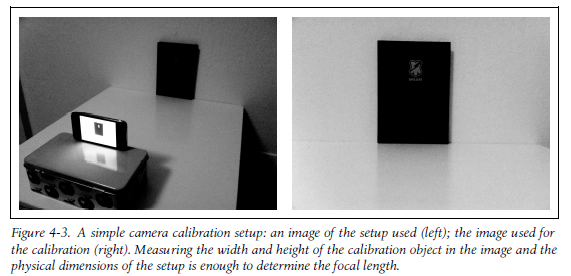

See Figure 4-3 for an example of a setup. Now, using similar triangles, the following relation gives the focal lengths:

$$f_x = \frac{\Delta x}{\Delta X} \ \Delta Z \ , \ \ f_y = \frac{\Delta y}{\Delta Y} \ \Delta Z$$

For the particular setup in Figure 4-3, the object was measured to be 130 by 185 mm, so $\Delta X = 130$ and $\Delta Y = 185$. The distance from camera to object was 460 mm, so $\Delta Z = 460$. You can use any unit of measurement; only the ratios of the measurements matter. Using ginput() to select four points in the image, the width and height in pixels was 722 and 1040. This means that $\Delta x = 722$ and $\Delta y = 1040$. Putting these values in the relationship above gives

$$f_x = 2555 \ \ \text{and} \ \ f_y = 2586$$

Now, it is important to note that this is for a particular image resolution. In this case, the image was 2592 × 1936 pixels. Remember that the focal length and the optical center are measured in pixels and scale with the image resolution. If you take other image resolutions (for example a thumbnail image), the values will change. It is convenient to add the constants of your camera to a helper function like this:

In [5]:
from numpy import *

def my_calibration(sz):
  row,col = sz
  fx = 2555*col/2592
  fy = 2586*row/1936
  K = diag([fx,fy,1])
  K[0,2] = 0.5*col
  K[1,2] = 0.5*row
  return K

my_calibration((2592,1936))

array([[1.90836420e+03, 0.00000000e+00, 9.68000000e+02],
       [0.00000000e+00, 3.46224793e+03, 1.29600000e+03],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])

This function then takes a size tuple and returns the calibration matrix. Here we assume the optical center to be the center of the image. Go ahead and replace the focal lengths with their mean if you like; for most consumer type cameras this is fine. Note that the calibration is for images in landscape orientation. For portrait orientation, you need to interchange the constants. Let’s keep this function and make use of it in the next section.

***Pose estimation from planes and markers***

Previously, we saw how to estimate homographies between planes. Combining this with a calibrated camera makes it possible to compute the camera’s pose (rotation and translation) if the image contains a planar marker object. This marker object can be almost any flat object.

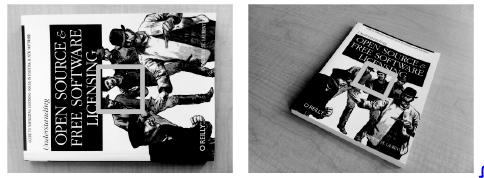

The following example is given in Solem. Consider the two above images (book_frontal.jpg and book_perspective.jpg available in the same directory as this notebook). SIFT features are extracted from both images and a robust estimate of a homography is obtained using RANSAC.

In [6]:
import cv2
cv2.SIFT_create()

< cv2.SIFT 0000021DDF6815B0>

In [1]:
def process_image(imagename,resultname,params="--edge-thresh 10 --peak-thresh 5"):

    sft = cv2.SIFT_create()
    """ Process an image and save the results in a file. """

    if imagename[-3:] != 'pgm':
        # create a pgm file
        im = Image.open(imagename).convert('L')
        im.save('tmp.pgm')
        imagename = 'tmp.pgm'

    resultname = sft.detect(imagename,None)
    
    print('processed', imagename, 'to', resultname)

In [ ]:
import cv2 as cv

image = cv.imread("empire.jpg")
gray_image = cv.cvtColor(image,cv.COLOR_BGR2GRAY)

sft = cv.xfeatures2d.SIFT_create()
keyPoints = sft.detect(image,None)

output = cv.drawKeypoints(image,keyPoints,None)

cv.imshow("FEATURES DETECTED",output)
cv.imshow("NORMAL",image)

cv.waitKey(0)
cv.destroyAllWindows()

kp, des = sft.detectAndCompute(image,None)

imfront = cv.imread("book_frontal.JPG")
impersp = cv.imread("book_perspective.JPG")

l0, d0 = sft.detectAndCompute(imfront,None)
l1, d1 = sft.detectAndCompute(impersp,None)

In [ ]:
print(shape(d1))

In [ ]:
def cube_points(c,wid):
  """ Creates a list of points for plotting
  a cube with plot. (the first 5 points are
  the bottom square, some sides repeated). """
  p = []
  # bottom
  p.append([c[0]-wid,c[1]-wid,c[2]-wid])
  p.append([c[0]-wid,c[1]+wid,c[2]-wid])
  p.append([c[0]+wid,c[1]+wid,c[2]-wid])
  p.append([c[0]+wid,c[1]-wid,c[2]-wid])
  p.append([c[0]-wid,c[1]-wid,c[2]-wid]) # same as first to close plot
  # top
  p.append([c[0]-wid,c[1]-wid,c[2]+wid])
  p.append([c[0]-wid,c[1]+wid,c[2]+wid])
  p.append([c[0]+wid,c[1]+wid,c[2]+wid])
  p.append([c[0]+wid,c[1]-wid,c[2]+wid])
  p.append([c[0]-wid,c[1]-wid,c[2]+wid]) # same as first to close plot
  # vertical sides
  p.append([c[0]-wid,c[1]-wid,c[2]+wid])
  p.append([c[0]-wid,c[1]+wid,c[2]+wid])
  p.append([c[0]-wid,c[1]+wid,c[2]-wid])
  p.append([c[0]+wid,c[1]+wid,c[2]-wid])
  p.append([c[0]+wid,c[1]+wid,c[2]+wid])
  p.append([c[0]+wid,c[1]-wid,c[2]+wid])
  p.append([c[0]+wid,c[1]-wid,c[2]-wid])
  return array(p).T

In [18]:
import homography
import camera

sft = cv.xfeatures2d.SIFT_create()

def my_calibration(sz):
  row,col = sz
  fx = 2555*col/2592
  fy = 2586*row/1936
  K = diag([fx,fy,1])
  K[0,2] = 0.5*col
  K[1,2] = 0.5*row
  return K

# match features and estimate homography
matches = sft.match_twosided(d0,d1)
ndx = matches.nonzero()[0]
print(ndx)
fp = homography.make_homog(l0[ndx,:2].T)
ndx2 = [int(matches[i]) for i in ndx]
tp = homography.make_homog(l1[ndx2,:2].T)

model = homography.RansacModel()
H = homography.H_from_ransac(fp,tp,model)

# camera calibration
K = my_calibration((747,1000))

# 3D points at plane z=0 with sides of length 0.2
box = cube_points([0,0,0.1],0.1)

# project bottom square in first image
cam1 = camera.Camera( hstack((K,dot(K,array([[0],[0],[-1]])) )) )

# first points are the bottom square
box_cam1 = cam1.project(homography.make_homog(box[:,:5]))

# use H to transfer points to the second image
box_trans = homography.normalize(dot(H,box_cam1))

# compute second camera matrix from cam1 and H
cam2 = camera.Camera(dot(H,cam1.P))
A = dot(linalg.inv(K),cam2.P[:,:3])
A = array([A[:,0],A[:,1],cross(A[:,0],A[:,1])]).T
cam2.P[:,:3] = dot(K,A)

# project with the second camera
box_cam2 = cam2.project(homography.make_homog(box))

# test: projecting point on z=0 should give the same
point = array([1,1,0,1]).T
print(homography.normalize(dot(dot(H,cam1.P),point)))
print(cam2.project(point))

AttributeError: 'cv2.SIFT' object has no attribute 'match_twosided'

In [1]:
import cv2
sift = cv2.SIFT_create()

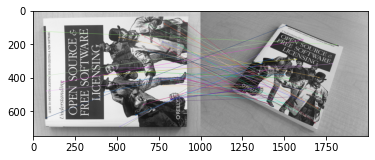

(<matplotlib.image.AxesImage at 0x18b2bcc7a30>, None)

In [4]:
import cv2                        
import matplotlib.pyplot as plt                       
%matplotlib inline                                               
# read images                       
img1 = cv2.imread('book_frontal.JPG')                         
img2 = cv2.imread('book_perspective.JPG')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY) 
#sift                       
sift = cv2.SIFT_create()
keypoints_1, descriptors_1 = sift.detectAndCompute(img1,None)
keypoints_2, descriptors_2 = sift.detectAndCompute(img2,None)
#feature matching                       
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)                                               
matches = bf.match(descriptors_1,descriptors_2)                       
matches = sorted(matches, key = lambda x:x.distance)                                               
img3 = cv2.drawMatches(img1, keypoints_1, img2, keypoints_2, matches[:50], img2, flags=2)                       
plt.imshow(img3),plt.show()